**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade Aula 3.4

# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 65.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.31MB/s]


Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.0128,  0.9133,  0.0815, -0.2493,  0.1817, -0.6798, -0.3075,  0.9213,
          0.5479, -1.0344]], grad_fn=<AddmmBackward0>)

In [7]:
model(dataset_train[0][0].view(-1, 784))

tensor([[ 0.0990,  0.1042, -0.0068, -0.2170,  0.0276, -0.1017,  0.1254,  0.2786,
         -0.1832, -0.1279]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [8]:
n_epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [9]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = x_train.view(-1, 28 * 28)
        labels = y_train

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = x_val.view(-1, 28 * 28)
            labels_val = y_val

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 0.4089, Train Acc: 0.8817, Val Loss: 0.3336, Val Acc: 0.9083
Epoch [2/10], Train Loss: 0.3082, Train Acc: 0.9120, Val Loss: 0.3199, Val Acc: 0.9128
Epoch [3/10], Train Loss: 0.2924, Train Acc: 0.9164, Val Loss: 0.3120, Val Acc: 0.9152
Epoch [4/10], Train Loss: 0.2839, Train Acc: 0.9197, Val Loss: 0.3134, Val Acc: 0.9150
Epoch [5/10], Train Loss: 0.2771, Train Acc: 0.9223, Val Loss: 0.3062, Val Acc: 0.9169
Epoch [6/10], Train Loss: 0.2729, Train Acc: 0.9236, Val Loss: 0.3114, Val Acc: 0.9138
Epoch [7/10], Train Loss: 0.2686, Train Acc: 0.9238, Val Loss: 0.3009, Val Acc: 0.9201
Epoch [8/10], Train Loss: 0.2670, Train Acc: 0.9250, Val Loss: 0.3009, Val Acc: 0.9183
Epoch [9/10], Train Loss: 0.2637, Train Acc: 0.9261, Val Loss: 0.3041, Val Acc: 0.9197
Epoch [10/10], Train Loss: 0.2615, Train Acc: 0.9266, Val Loss: 0.3010, Val Acc: 0.9203


In [10]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2615
Última acurácia de treinamento: 0.9266
Última perda de validação: 0.3010
Última acurácia de validação: 0.9203


### Visualizando a evolução da perda e acurácia

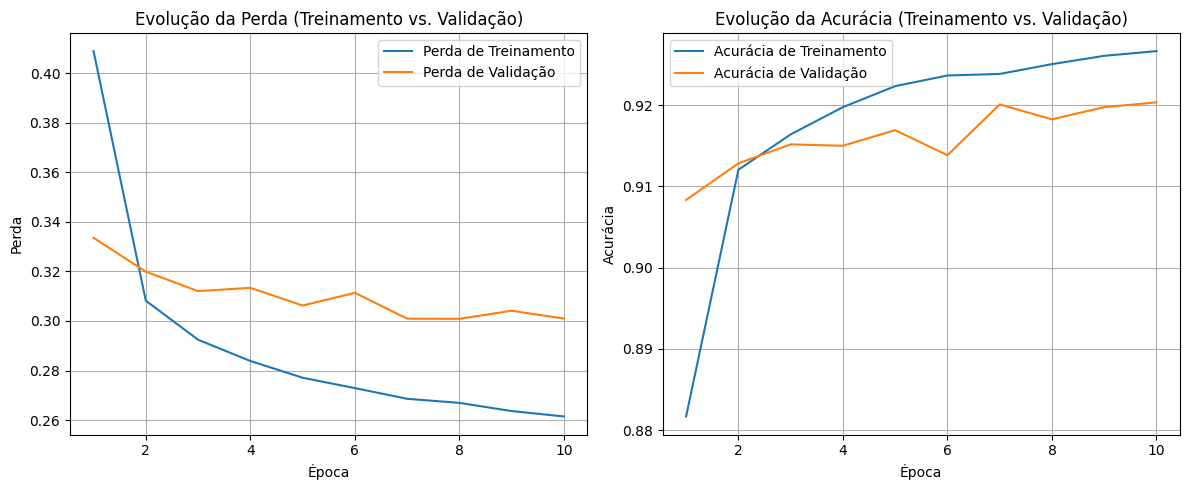

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

R.: batch_size = 100

2. Em uma época, quantos mini-batches existem?

R.: 42000 valores de X_train. 42000/100 = 420 mini-batches

3. Qual é a definição de época?

R.: Quando o modelo calcula e ajusta os pesos baseado em todos os elementos do dataset (em todos os mini-batches)


## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

In [12]:
# Exercícios 1 e 2
# Exercício 1: print no final de cada minibatch
# Exercício 2: treina com diferentes batch_sizes e armazena as perdas por época para comparação

batch_sizes_to_test = [10, 100, 500]
results = {}  # { batch_size: [avg_train_loss_per_epoch, ...] }

for bs in batch_sizes_to_test:
    print(f'\n=== Treinando com batch_size = {bs} ===')

    # Recria os loaders com o novo batch_size
    loader_tr = DataLoader(dataset_train, batch_size=bs, shuffle=True)
    loader_vl = DataLoader(dataset_val,   batch_size=bs, shuffle=False)

    # Reinicia o modelo e o otimizador para cada experimento
    model_bs = torch.nn.Linear(28 * 28, 10)
    optimizer_bs = torch.optim.SGD(model_bs.parameters(), lr=learningRate)

    epoch_losses = []

    for epoch in range(n_epochs):
        model_bs.train()
        running_loss = 0.0

        for batch_idx, (xb, yb) in enumerate(loader_tr):
            inputs  = xb.view(-1, 28 * 28)
            outputs = model_bs(inputs)
            loss    = criterion(outputs, yb)

            optimizer_bs.zero_grad()
            loss.backward()
            optimizer_bs.step()

            running_loss += loss.item()

            # Exercício 1: print no final de cada minibatch
            print(f'Época: {epoch + 1}/{n_epochs}, batch: {batch_idx + 1}')

        avg_loss = running_loss / len(loader_tr)
        epoch_losses.append(avg_loss)
        print(f'  --> Fim da época {epoch + 1}/{n_epochs} | Loss médio: {avg_loss:.4f}')

    results[bs] = epoch_losses

A saída de streaming foi truncada nas últimas 5000 linhas.
Época: 2/10, batch: 302
Época: 2/10, batch: 303
Época: 2/10, batch: 304
Época: 2/10, batch: 305
Época: 2/10, batch: 306
Época: 2/10, batch: 307
Época: 2/10, batch: 308
Época: 2/10, batch: 309
Época: 2/10, batch: 310
Época: 2/10, batch: 311
Época: 2/10, batch: 312
Época: 2/10, batch: 313
Época: 2/10, batch: 314
Época: 2/10, batch: 315
Época: 2/10, batch: 316
Época: 2/10, batch: 317
Época: 2/10, batch: 318
Época: 2/10, batch: 319
Época: 2/10, batch: 320
Época: 2/10, batch: 321
Época: 2/10, batch: 322
Época: 2/10, batch: 323
Época: 2/10, batch: 324
Época: 2/10, batch: 325
Época: 2/10, batch: 326
Época: 2/10, batch: 327
Época: 2/10, batch: 328
Época: 2/10, batch: 329
Época: 2/10, batch: 330
Época: 2/10, batch: 331
Época: 2/10, batch: 332
Época: 2/10, batch: 333
Época: 2/10, batch: 334
Época: 2/10, batch: 335
Época: 2/10, batch: 336
Época: 2/10, batch: 337
Época: 2/10, batch: 338
Época: 2/10, batch: 339
Época: 2/10, batch: 340
Época

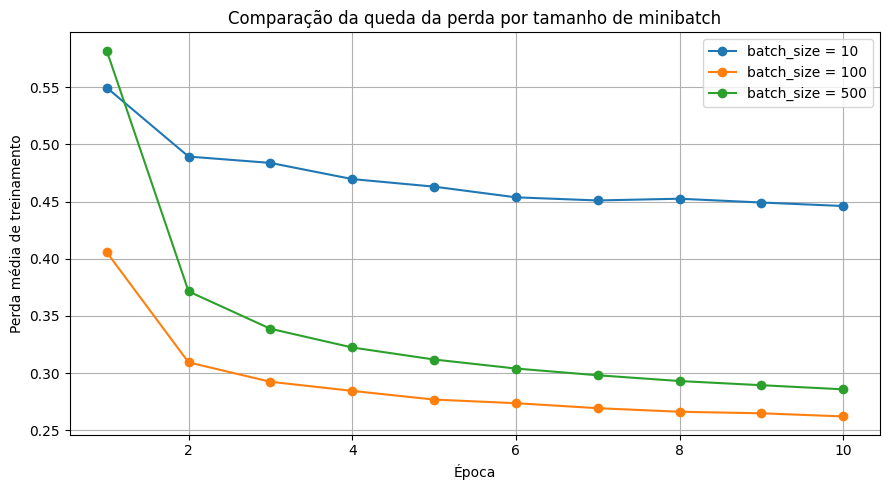

In [13]:
# Exercício 2: gráfico comparativo da queda da perda por batch_size
plt.figure(figsize=(9, 5))

for bs, losses in results.items():
    plt.plot(range(1, n_epochs + 1), losses, marker='o', label=f'batch_size = {bs}')

plt.xlabel('Época')
plt.ylabel('Perda média de treinamento')
plt.title('Comparação da queda da perda por tamanho de minibatch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusões sobre os experimentos deste notebook
